In [1]:
import glob
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timezone

In [2]:
DATA_DIR = Path('../../data/lab03/sun_calibration')

paths = sorted(DATA_DIR.glob('sun-cal-*.npz'))
files = [np.load(p) for p in paths]
print(f'Loaded {len(files)} files from {DATA_DIR.resolve()}')

# Frequency axis (IF only — LO omitted)
f0 = files[0]
F_S_HZ  = float(f0['f_s_hz']) if 'f_s_hz' in f0 else 500e6
N_TOTAL = int(f0['corr'].shape[0])           # 512 (new captures) or 1024 (old)
N_POS   = 512 if N_TOTAL == 1024 else N_TOTAL
DF_HZ   = F_S_HZ / 1024                     # channel spacing

freqs_mhz = np.arange(N_POS) * DF_HZ / 1e6  # 0 – ~249.5 MHz
print(f'IF axis: {freqs_mhz[0]:.1f} – {freqs_mhz[-1]:.1f} MHz  '
      f'({DF_HZ/1e3:.1f} kHz/channel,  {N_POS} channels)')

Loaded 10 files from /Users/junruiting/GitHub/ay-121/data/lab03/sun_calibration
IF axis: 0.0 – 249.5 MHz  (488.3 kHz/channel,  512 channels)


In [3]:
print(f'{"#":<4} {"UTC time":<24} {"Alt (deg)":>10} {"Az (deg)":>10} {"n_acc":>6}')
print('-' * 58)
for i, f in enumerate(files):
    t = datetime.fromtimestamp(float(f['unix_time']), tz=timezone.utc).strftime('%Y-%m-%d %H:%M:%S UTC')
    print(f'{i:<4} {t:<24} {float(f["alt_deg"]):>10.2f} {float(f["az_deg"]):>10.2f} {int(f["n_acc"]):>6}')

#    UTC time                  Alt (deg)   Az (deg)  n_acc
----------------------------------------------------------
0    2026-03-16 22:03:11 UTC       43.78     217.81     10
1    2026-03-16 22:03:29 UTC       43.70     217.99     10
2    2026-03-16 22:03:43 UTC       43.67     218.08     10
3    2026-03-16 22:03:56 UTC       43.64     218.15     10
4    2026-03-16 22:04:10 UTC       43.61     218.22     10
5    2026-03-16 22:04:24 UTC       43.59     218.28     10
6    2026-03-16 22:04:38 UTC       43.56     218.35     10
7    2026-03-16 22:04:51 UTC       43.53     218.42     10
8    2026-03-16 22:05:05 UTC       43.50     218.49     10
9    2026-03-16 22:05:19 UTC       43.47     218.56     10


/var/folders/k_/sywjddzn17s8zyyk8mpk4nz80000gn/T/ipykernel_54013/2373840443.py:10: RuntimeWarning: divide by zero encountered in log10
  power_db = 10 * np.log10(np.abs(corr_pos))


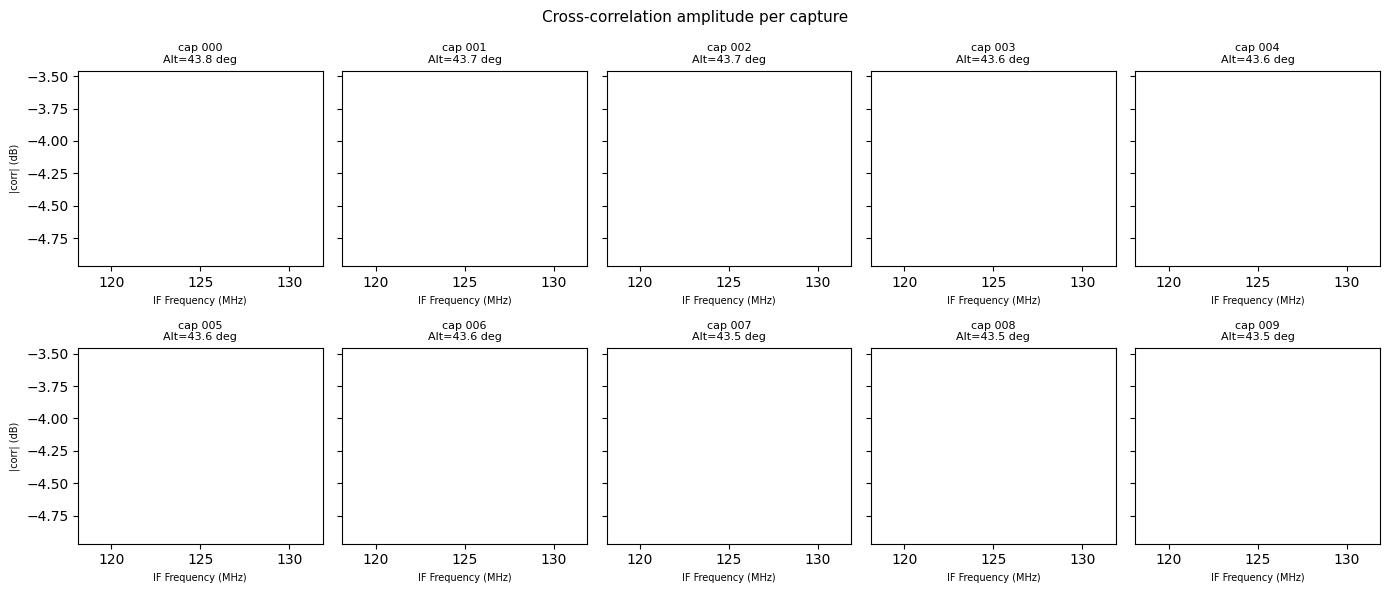

In [4]:
n = len(files)
ncols = 5
nrows = max(1, int(np.ceil(n / ncols)))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3 * nrows), sharey=True)
axes = np.array(axes).flatten()

for i, f in enumerate(files):
    corr_pos = f['corr'][:N_POS][1:]          # skip DC bin (ch 0)
    power_db = 10 * np.log10(np.abs(corr_pos))
    axes[i].plot(freqs_mhz[1:], power_db, lw=0.8)
    axes[i].set_title(f'cap {i:03d}\nAlt={float(f["alt_deg"]):.1f} deg', fontsize=8)
    axes[i].set_xlabel('IF Frequency (MHz)', fontsize=7)
    if i % ncols == 0:
        axes[i].set_ylabel('|corr| (dB)', fontsize=7)

for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle('Cross-correlation amplitude per capture', fontsize=11)
plt.tight_layout()
plt.show()

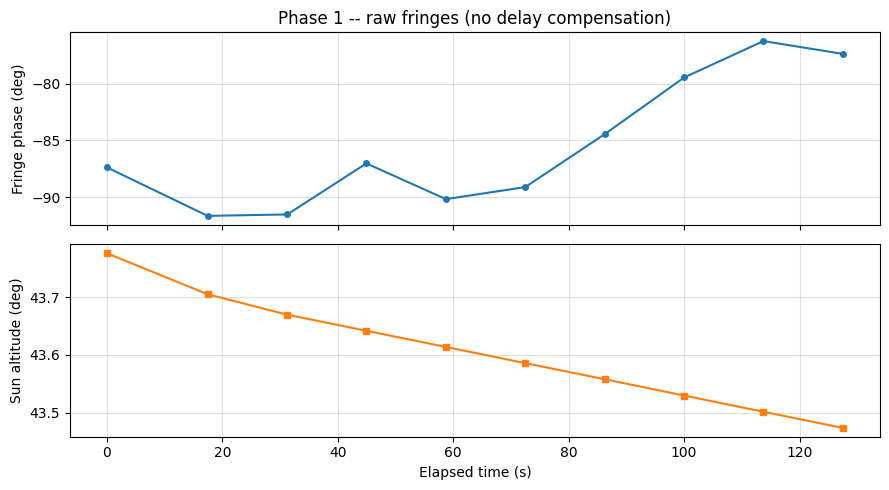

In [5]:
times      = np.array([float(f['unix_time']) for f in files])
# Positive-frequency half, excluding DC (ch 0 = 10 GHz, no fringe info)
fringe_phi = np.array([np.angle(f['corr'][:N_POS][1:].sum()) for f in files])
alt        = np.array([float(f['alt_deg']) for f in files])

t_sec = times - times[0]

fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)

axes[0].plot(t_sec, np.degrees(fringe_phi), 'o-', ms=4)
axes[0].set_ylabel('Fringe phase (deg)')
axes[0].set_title('Phase 1 -- raw fringes (no delay compensation)')
axes[0].grid(True, alpha=0.4)

axes[1].plot(t_sec, alt, 's-', ms=4, color='C1')
axes[1].set_ylabel('Sun altitude (deg)')
axes[1].set_xlabel('Elapsed time (s)')
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

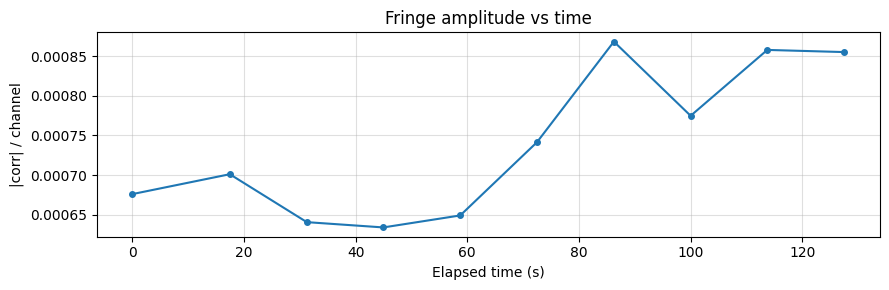

In [6]:
fringe_amp = np.array([np.abs(f['corr'][:N_POS][1:].sum()) / (N_POS - 1) for f in files])

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(t_sec, fringe_amp, 'o-', ms=4)
ax.set_xlabel('Elapsed time (s)')
ax.set_ylabel('|corr| / channel')
ax.set_title('Fringe amplitude vs time')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()